In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Define constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease")

print("Path to dataset files:", path)

DATA_DIR = path + '/PlantVillage/'

Using Colab cache for faster access to the 'plantdisease' dataset.
Path to dataset files: /kaggle/input/plantdisease


In [ ]:
# Create the training dataset (80% of the data)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, 
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Create the validation dataset (20% of the data)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, 
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Get the class names from the directory structure
class_names = train_dataset.class_names
print(f"Found {len(class_names)} classes: {class_names[:5]}...") # Print first 5 classes

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Found 15 classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']...


In [ ]:
# Print and save class names
print("Class names in order:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

# Save class names to a file
import json
with open('class_names.json', 'w') as f:
    json.dump(class_names, f, indent=2)

Class names in order:
0: Pepper__bell___Bacterial_spot
1: Pepper__bell___healthy
2: Potato___Early_blight
3: Potato___Late_blight
4: Potato___healthy
5: Tomato_Bacterial_spot
6: Tomato_Early_blight
7: Tomato_Late_blight
8: Tomato_Leaf_Mold
9: Tomato_Septoria_leaf_spot
10: Tomato_Spider_mites_Two_spotted_spider_mite
11: Tomato__Target_Spot
12: Tomato__Tomato_YellowLeaf__Curl_Virus
13: Tomato__Tomato_mosaic_virus
14: Tomato_healthy


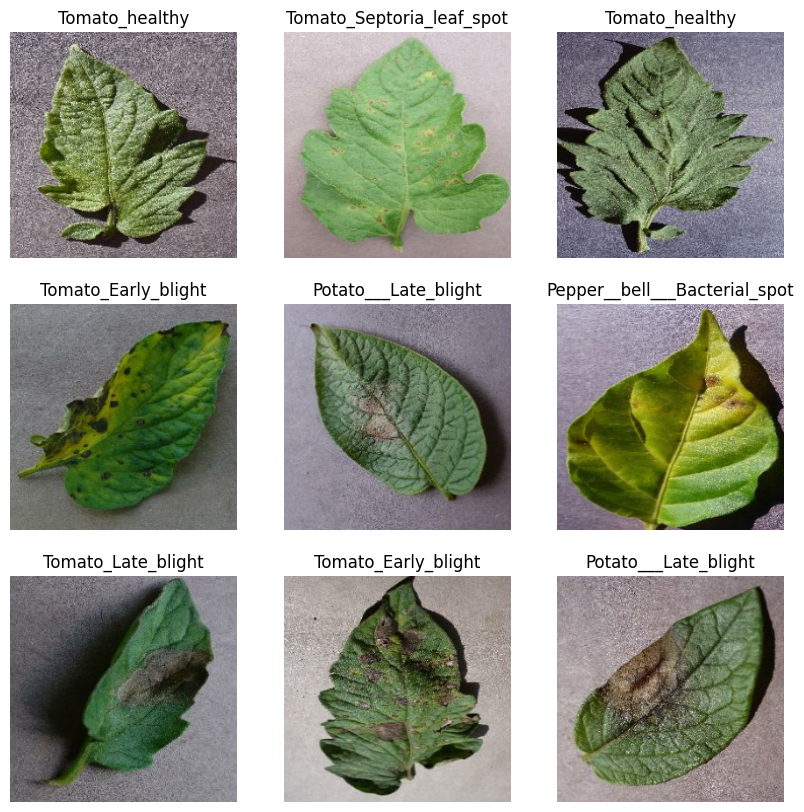

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache('.tfdata_cache').shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.RandomZoom(0.3),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

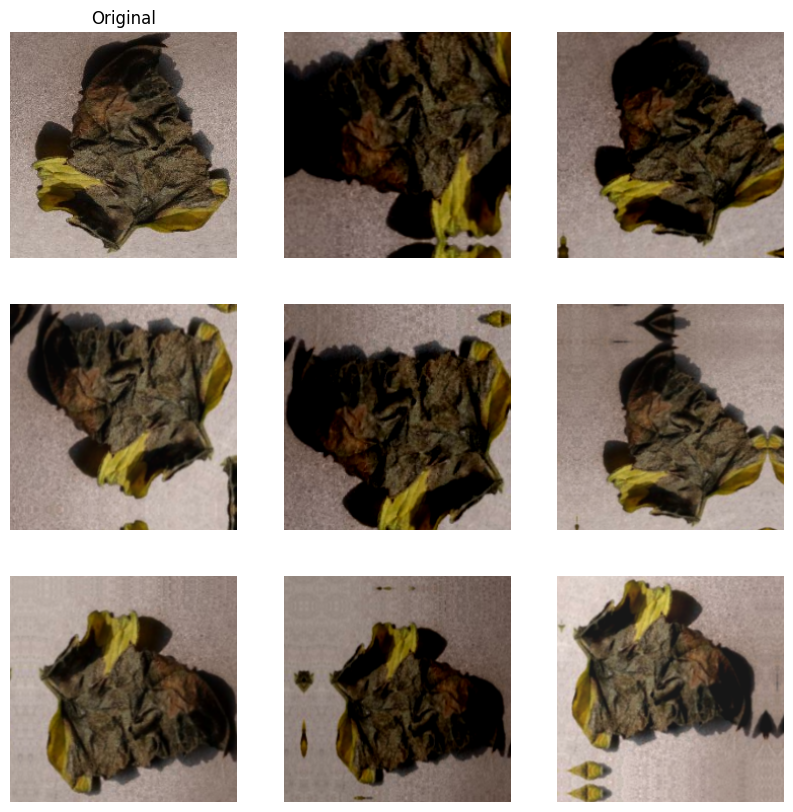

In [ ]:
# Remove the cache lockfile if it exists
import os
lock_file = '.tfdata_cache_0.lockfile'
if os.path.exists(lock_file):
    os.remove(lock_file)

for image, _ in train_dataset.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[0]

  # Display the original image
  ax = plt.subplot(3, 3, 1)
  plt.imshow(first_image.numpy().astype("uint8"))
  plt.title("Original")
  plt.axis("off")

  # Create 8 copies and augment them in a single call (much faster)
  sample = tf.expand_dims(first_image, 0)                 # shape (1, H, W, C)
  repeated = tf.repeat(sample, repeats=8, axis=0)         # shape (8, H, W, C)

  @tf.function
  def augment_batch(x):
    return data_augmentation(x)

  augmented_batch = augment_batch(repeated)               # runs once for all 8
  aug_np = augmented_batch.numpy().astype("uint8")        # single conversion to numpy

  for i in range(8):
    ax = plt.subplot(3, 3, i + 2)
    plt.imshow(aug_np[i])
    plt.axis("off")
  plt.show()

In [ ]:
# Create a layer to rescale pixel values as ResNet expects
preprocess_input = tf.keras.applications.resnet_v2.preprocess_input

# Load the base model (ResNet50V2) with ImageNet weights, without its final layer
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.ResNet50V2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

In [ ]:
base_model.trainable = False

In [ ]:
# Get the number of classes
num_classes = len(class_names)

# Build the model
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False) # Run base model in inference mode
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x) # Regularization
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        30,735 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,595,535 (90.01 MB)

 Trainable params: 30,735 (120.06 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [ ]:
# Compile the model with an optimizer, loss function, and metrics
base_learning_rate = 0.001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [ ]:
# Train the model for 10 epochs
initial_epochs = 10
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 91s 143ms/step - accuracy: 0.5187 - loss: 1.5322 - val_accuracy: 0.7747 - val_loss: 0.6842
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 80s 138ms/step - accuracy: 0.7601 - loss: 0.7203 - val_accuracy: 0.8265 - val_loss: 0.5351
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 80s 138ms/step - accuracy: 0.7994 - loss: 0.6237 - val_accuracy: 0.8268 - val_loss: 0.5339
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 78s 138ms/step - accuracy: 0.8058 - loss: 0.5840 - val_accuracy: 0.8299 - val_loss: 0.5161
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 80s 138ms/step - accuracy: 0.8117 - loss: 0.5558 - val_accuracy: 0.8435 - val_loss: 0.4620
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 80s 138ms/step - accuracy: 0.8198 - loss: 0.5554 - val_accuracy: 0.8263 - val_loss: 0.5314
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 79s 138ms/step - accuracy: 0.8236 - loss: 0.5354 - val_accuracy: 0.8476 - val_loss: 0.4591
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 77s 137ms/step - accuracy: 0.8174 - loss: 0

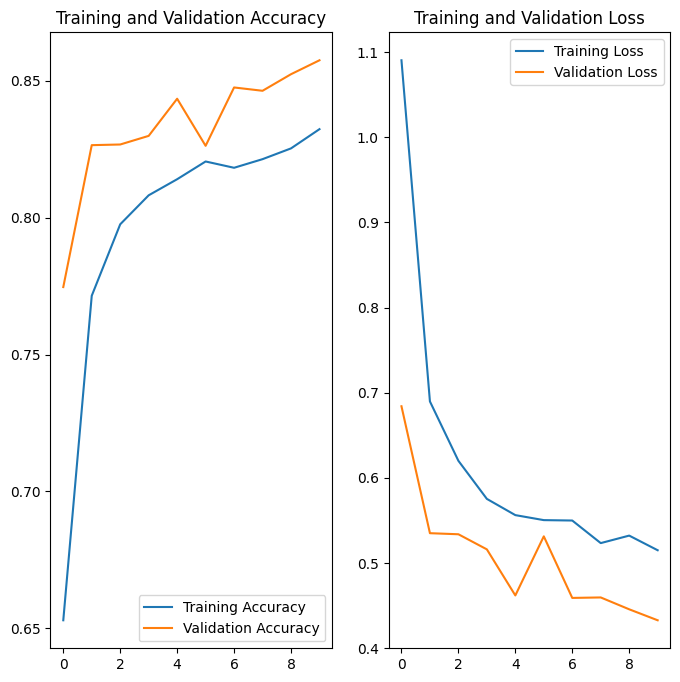

In [ ]:
# Get the training and validation accuracy and loss from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(initial_epochs)

# Plot the results
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# Unfreeze the base model
base_model.trainable = True


print("Number of layers in the base model: ", len(base_model.layers))
fine_tune_at = 80

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

Number of layers in the base model:  190


In [ ]:
# Compile the model with a very low learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate / 10),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        30,735 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,595,535 (90.01 MB)

 Trainable params: 22,317,839 (85.14 MB)

 Non-trainable params: 1,277,696 (4.87 MB)

In [ ]:
# Continue training for 10 more epochs
fine_tune_epochs = 10
total_epochs = initial_epochs + fine_tune_epochs

history_fine = model.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=history.epoch[-1],
                         validation_data=validation_dataset)

Epoch 10/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 178s 285ms/step - accuracy: 0.8255 - loss: 0.5250 - val_accuracy: 0.9111 - val_loss: 0.2906
Epoch 11/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 153s 279ms/step - accuracy: 0.9332 - loss: 0.1947 - val_accuracy: 0.9372 - val_loss: 0.2049
Epoch 12/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 153s 279ms/step - accuracy: 0.9527 - loss: 0.1361 - val_accuracy: 0.9385 - val_loss: 0.1811
Epoch 13/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 153s 278ms/step - accuracy: 0.9630 - loss: 0.1000 - val_accuracy: 0.9515 - val_loss: 0.1601
Epoch 14/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 152s 278ms/step - accuracy: 0.9673 - loss: 0.0958 - val_accuracy: 0.9399 - val_loss: 0.1956
Epoch 15/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 149s 278ms/step - accuracy: 0.9695 - loss: 0.0850 - val_accuracy: 0.9535 - val_loss: 0.1371
Epoch 16/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 150s 278ms/step - accuracy: 0.9750 - loss: 0.0749 - val_accuracy: 0.9455 - val_loss: 0.1852
Epoch 17/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 150s 278ms/step - accuracy: 

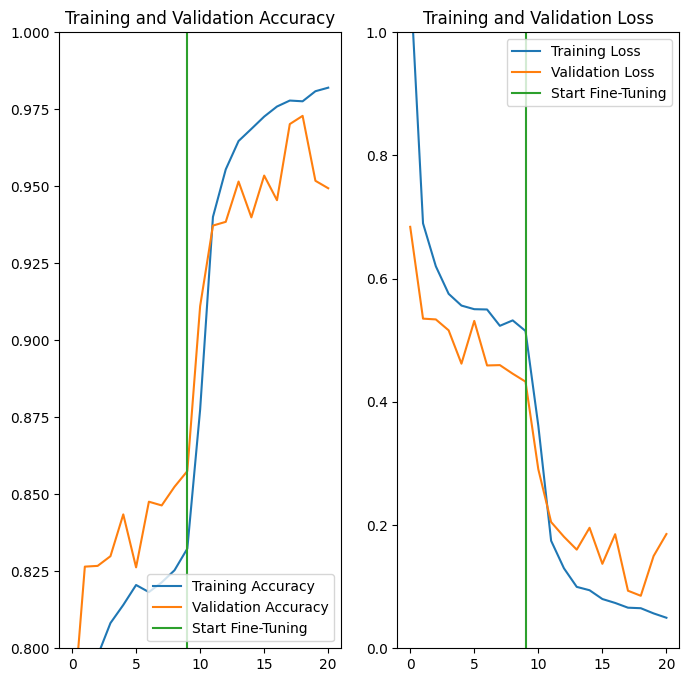

In [ ]:
# Append the fine-tuning history to the initial history
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']
loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

# Plot the combined history
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1, initial_epochs-1],
          plt.ylim(), label='Start Fine-Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1, initial_epochs-1],
         plt.ylim(), label='Start Fine-Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
import os

model.save('plant_disease_model.keras')
print("Model saved successfully as plant_disease_model.keras")

file_path = 'plant_disease_model.keras'
file_size_bytes = os.path.getsize(file_path)
file_size_mb = file_size_bytes / (1024 * 1024)

print(f"The size of the model file is: {file_size_mb:.2f} MB")

Model saved successfully as plant_disease_model.keras
The size of the model file is: 261.02 MB
